Estimation de l'effet causal de la fermeture des établissement 'social' sur le vote RN à l'aide d'un staggered DID

Import des bibliothèques

In [23]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from did_multiplegt_dyn import DidMultiplegtDyn  

Import des données

In [24]:
# Social
df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
df_rnp['codecommune'] = df_rnp['codecommune'].astype(str).str.zfill(5)

df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
df_rp['codecommune'] = df_rp['codecommune'].astype(str).str.zfill(5)

df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)
df_ui['codecommune'] = df_ui['codecommune'].astype(str).str.zfill(5)

df_ud = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_d.csv", index_col=0)
df_ud['codecommune'] = df_ud['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_15672\2641705729.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_15672\2641705729.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_15672\2641705729.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)


Fonction d'attribution du traitement

In [25]:
def traitement(df):
    # 1. On définit notre seuil de traitement à partir de l'année 2002
    df_2002 = df[df['Annee'] == 1998].copy()
    df_2002['seuil'] = df_2002['total_equipements'] * 1.2

    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['seuil']
    df['seuil'] = df['codecommune'].map(mapping_seuil)

    # 3. Première passe : condition simple (1 si on passe sous le seuil, 0 sinon)
    df['traitée'] = (df['total_equipements'] > df['seuil']).astype(int)

    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])

    # 5. L'EFFET CLIQUET : On applique un maximum cumulé par commune.
    # Dès qu'une commune obtient un 1, toutes les lignes suivantes pour cette commune vaudront 1.
    df['traitée'] = df.groupby('codecommune')['traitée'].cummax()

    return df

In [36]:
df_rnp

,codecommune,Annee,pop,propf,prop014,prop1539,prop4059,prop60p,petranger,pcapi,...,revmoy,abstention_pres,vote_RN_pres,vote_PS_pres,abstention_leg,vote_RN_leg,vote_PS_leg,total_equipements,seuil,traitée
0,01001,1995,662,0.471756,0.268702,0.280916,0.258015,0.192366,0.016320,0.294118,...,12110.340,0.201285,0.225352,0.247887,NaN,NaN,NaN,0.0,0.0,0
1,01001,1996,678,0.468657,0.270149,0.270149,0.265672,0.194030,0.017366,0.297521,...,11530.236,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
2,01001,1997,695,0.467930,0.272595,0.259475,0.271137,0.196793,0.016997,0.298387,...,12207.807,NaN,NaN,NaN,0.337607,0.200680,0.316327,0.0,0.0,0
3,01001,1998,711,0.465714,0.272857,0.250000,0.278571,0.198571,0.018006,0.305882,...,12892.058,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
4,01001,1999,728,0.463687,0.273743,0.240223,0.284916,0.201117,0.018945,0.307692,...,12839.338,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330535,90095,2018,435,0.473430,0.106280,0.301932,0.371981,0.219807,0.016129,0.308219,...,20000.578,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1
330536,90095,2019,434,0.469438,0.085575,0.315403,0.376528,0.222494,0.013889,0.294521,...,20123.869,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1
330537,90095,2020,430,0.466667,0.064198,0.328395,0.382716,0.224691,0.013953,0.273973,...,20654.547,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1
330538,90095,2021,426,0.464020,0.047146,0.342432,0.387097,0.223325,0.011682,0.253425,...,20757.051,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1


## Calcul du traitement

### RNP

In [26]:
df_rnp = traitement(df_rnp)

### RP

In [27]:
df_rp = traitement(df_rp)

### UI

In [28]:
df_ui = traitement(df_ui)

### UD

In [29]:
df_ud = traitement(df_ud)

## DID

Definition du modele

In [30]:
def DID (df, election, annee_deb, parti) :
    # 1. On filtre la base pour ne garder que les années d'élection présidentielle
    annees_pres = [annee_deb, 2002, 2007, 2012, 2017, 2022]
    df_pres = df[df['Annee'].isin(annees_pres)].copy()

    # 2. Nettoyage : on retire les lignes avec des valeurs manquantes essentielles
    df_pres = df_pres.dropna(subset=[f'vote_{parti}_{election}', 'traitée'])

    # 3. On force les types en formats "simples" (Numpy) pour faciliter la conversion
    # (Cela vous évite l'erreur PyArrow)
    df_pres[f'vote_{parti}_{election}'] = df_pres[f'vote_{parti}_{election}'].astype('float64')
    df_pres['traitée'] = df_pres['traitée'].astype('float64')
    df_pres['Annee'] = df_pres['Annee'].astype('int64')
    # Note : S'il y a un souci avec 'codecommune' (par exemple si c'est un format 'object'),
    # vous pouvez aussi le forcer en string classique : df_pres['codecommune'] = df_pres['codecommune'].astype('str')

    # 4. Conversion en Polars
    df_pres_polars = pl.from_pandas(df_pres)

    # 5. Estimation Staggered DiD (avec le nom de classe corrigé)
    modele_did = DidMultiplegtDyn(
        df=df_pres_polars,         
        outcome=f'vote_{parti}_{election}',    # Variable dépendante
        group='codecommune',       # Identifiant du groupe
        time='Annee',              # Variable temporelle
        treatment='traitée',       # Indicateur de traitement
        placebo=2,                 # Tester 1 période avant le traitement (pre-trends)
        effects=5,                 # Estimer l'effet sur les 2 périodes suivant le traitement
        cluster='codecommune',      # Clustering des erreurs-types
        controls = ['pop', 'propf', 'prop014', 'prop1539', 'prop60p', 'petranger', 'pouem', 'pchom', 'paind','pbac', 'psup', 'revmoy']
    )

    modele_did.fit()
    modele_did.summary()
    modele_did.plot()
    return 

### RNP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002363 0.000634 -0.003605 -0.001120 36233.0     6334.0 36233.0       6334.0
            Effect_2 -0.005071 0.000834 -0.006705 -0.003437 27569.0     5750.0 27569.0       5750.0
            Effect_3 -0.006000 0.001095 -0.008147 -0.003853 20424.0     5165.0 20424.0       5165.0
            Effect_4 -0.008640 0.001434 -0.011450 -0.005829 13863.0     4330.0 13863.0       4330.0
            Effect_5 -0.009377 0.001863 -0.013028 -0.005725  7225.0     2814.0  7225.0       2814.0
Average_Total_Effect -0.005695 0.000867 -0.007394 -0.003995 54304.0    24393.0 54304.0      24393.0
           Placebo_1  0.000958 0.000865 -0.000737  0.002654 25280.0     3472.0 25280.0       3472.0
           Placebo_2  0.000640 0.001541 -0.002380  0.003661 10907.0     1380.0 10907.0       1380.0
Test of joint nullity of the effec

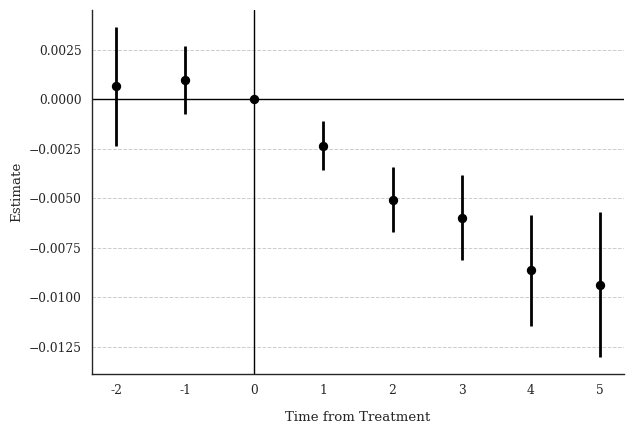

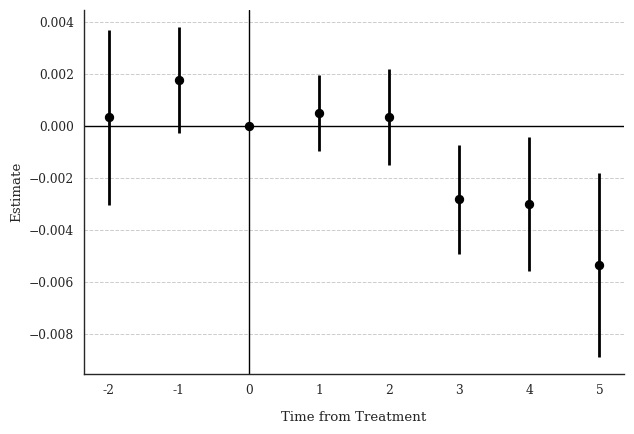

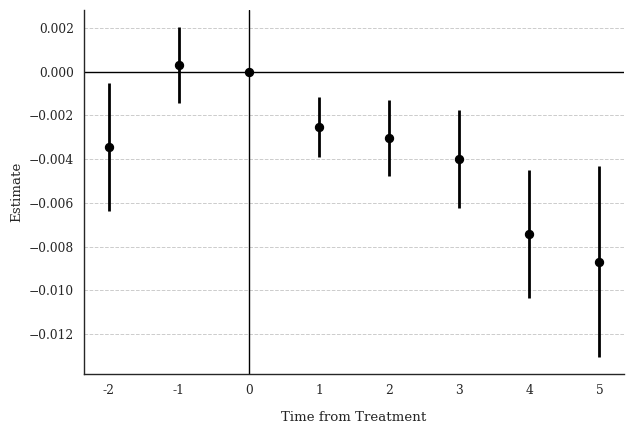

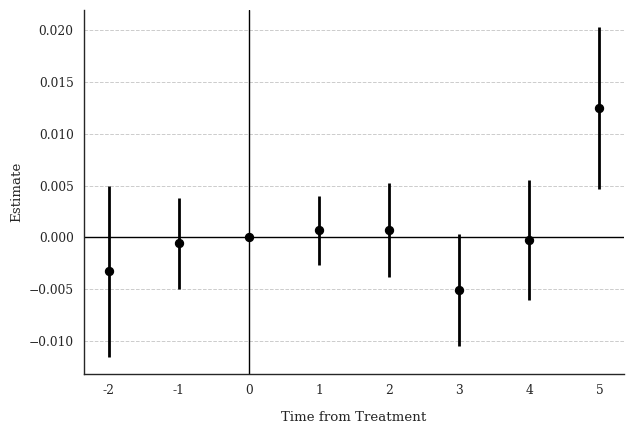

In [31]:
DID(df_rnp, 'pres', 1995, 'RN')
DID(df_rnp, 'pres', 1995, 'PS')

DID(df_rnp, 'leg', 1997, 'RN')
DID(df_rnp, 'leg', 1997, 'PS')

### RP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000408 0.000607 -0.001596  0.000781 33480.0     6130.0 33480.0       6130.0
            Effect_2 -0.001537 0.000821 -0.003146  0.000072 25537.0     5566.0 25537.0       5566.0
            Effect_3 -0.002501 0.001048 -0.004555 -0.000446 18978.0     5017.0 18978.0       5017.0
            Effect_4 -0.005035 0.001399 -0.007776 -0.002293 12968.0     4237.0 12968.0       4237.0
            Effect_5 -0.005829 0.001803 -0.009363 -0.002295  6929.0     2863.0  6929.0       2863.0
Average_Total_Effect -0.002588 0.000867 -0.004288 -0.000888 51169.0    23813.0 51169.0      23813.0
           Placebo_1  0.000312 0.000823 -0.001301  0.001926 23214.0     3249.0 23214.0       3249.0
           Placebo_2  0.001805 0.001617 -0.001364  0.004975 10043.0     1313.0 10043.0       1313.0
Test of joint nullity of the effec

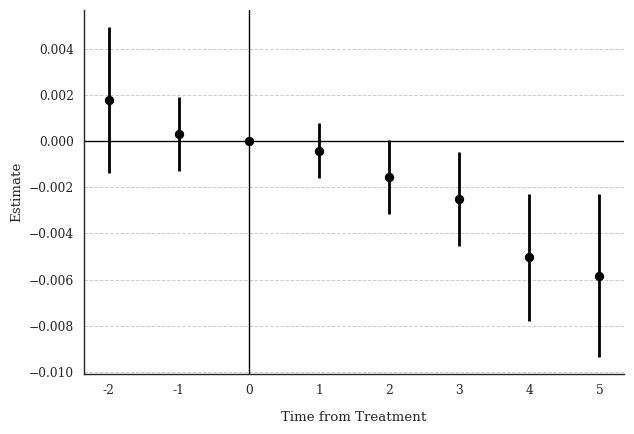

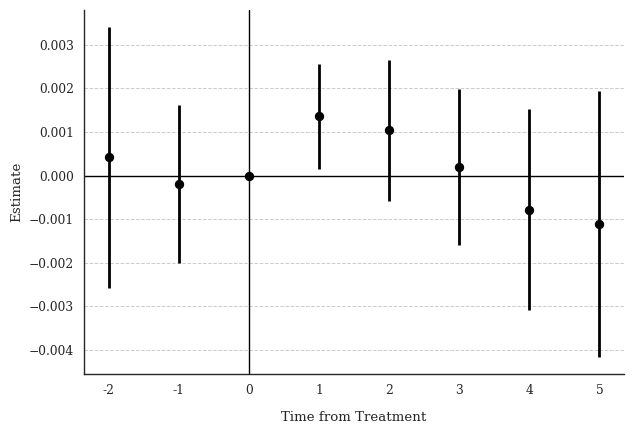

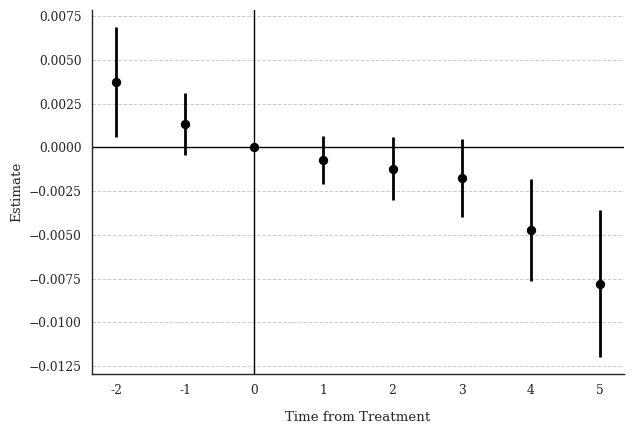

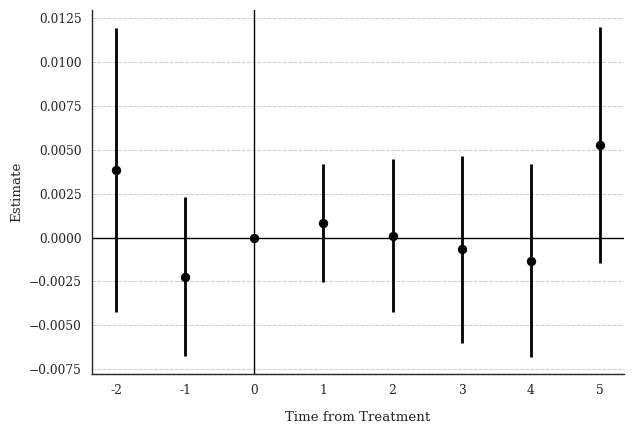

In [32]:
DID(df_rp, 'pres', 1995, 'RN')
DID(df_rp, 'pres', 1995, 'PS')

DID(df_rp, 'leg', 1997, 'RN')
DID(df_rp, 'leg', 1997, 'PS')

### UI

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000149 0.000796 -0.001710 0.001412 10554.0     1874.0 10554.0       1874.0
            Effect_2 -0.000473 0.001216 -0.002856 0.001911  8132.0     1699.0  8132.0       1699.0
            Effect_3 -0.000644 0.001590 -0.003760 0.002472  6063.0     1534.0  6063.0       1534.0
            Effect_4 -0.002505 0.002346 -0.007102 0.002093  4160.0     1309.0  4160.0       1309.0
            Effect_5 -0.001801 0.003066 -0.007810 0.004208  2300.0      962.0  2300.0        962.0
Average_Total_Effect -0.000960 0.001431 -0.003764 0.001844 16060.0     7378.0 16060.0       7378.0
           Placebo_1  0.003087 0.001092  0.000948 0.005227  7341.0      910.0  7341.0        910.0
           Placebo_2  0.007192 0.002160  0.002959 0.011425  3241.0      390.0  3241.0        390.0
Test of joint nullity of the effects: p-val

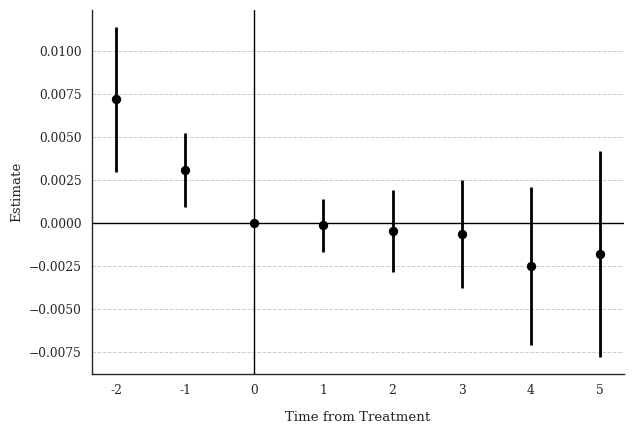

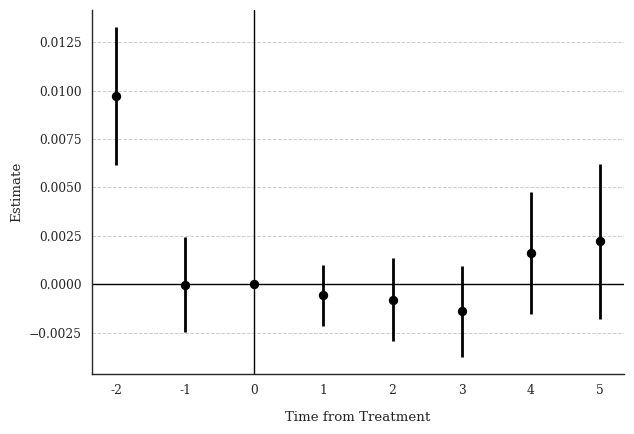

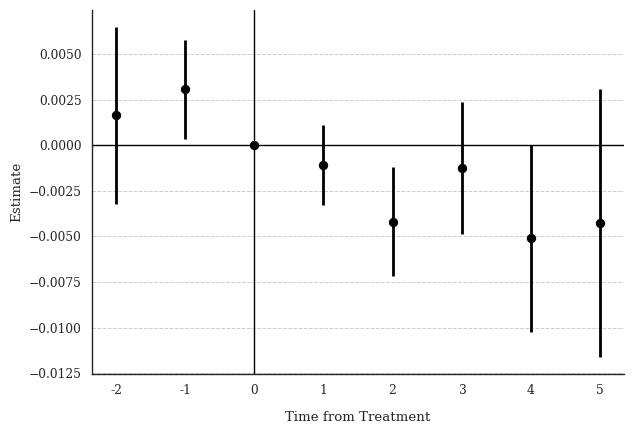

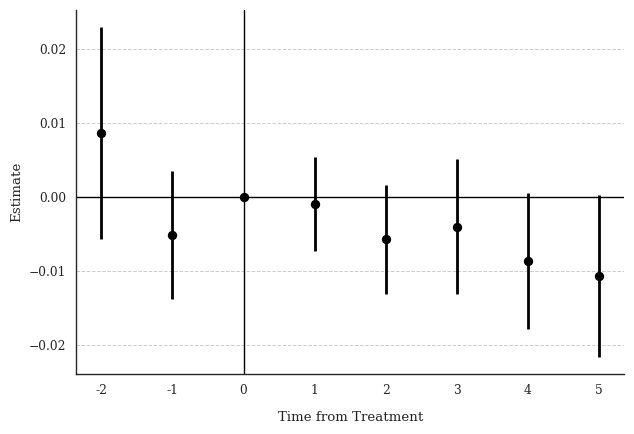

In [33]:
DID(df_ui, 'pres', 1995, 'RN')
DID(df_ui, 'pres', 1995, 'PS')

DID(df_ui, 'leg', 1997, 'RN')
DID(df_ui, 'leg', 1997, 'PS')

### UD

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.000287 0.001412 -0.002480 0.003054 2805.0      333.0 2805.0        333.0
            Effect_2  0.000774 0.002383 -0.003897 0.005445 2113.0      231.0 2113.0        231.0
            Effect_3  0.010092 0.003440  0.003349 0.016834 1503.0      174.0 1503.0        174.0
            Effect_4  0.015984 0.005290  0.005615 0.026353  950.0      136.0  950.0        136.0
            Effect_5  0.018894 0.007333  0.004521 0.033267  456.0      100.0  456.0        100.0
Average_Total_Effect  0.006256 0.002691  0.000982 0.011531 3446.0      974.0 3446.0        974.0
           Placebo_1  0.001592 0.001583 -0.001511 0.004694 2115.0      233.0 2115.0        233.0
           Placebo_2  0.002786 0.003136 -0.003360 0.008933  909.0       95.0  909.0         95.0
Test of joint nullity of the effects: p-value = 0.000388
Test

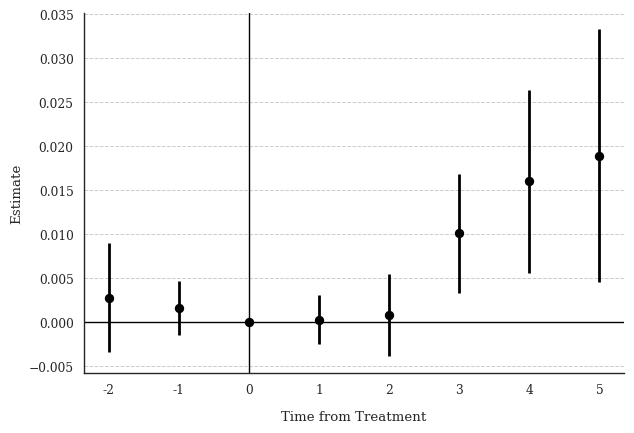

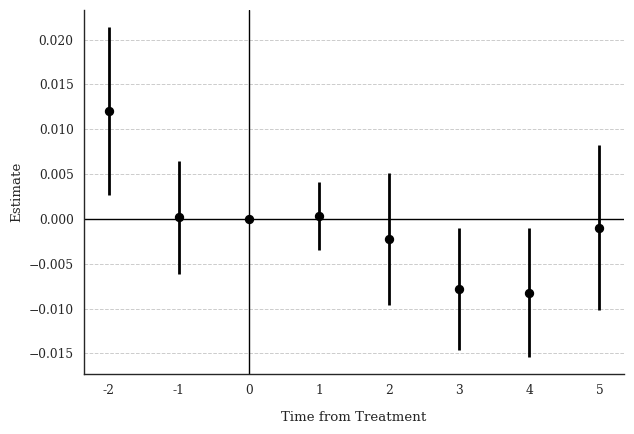

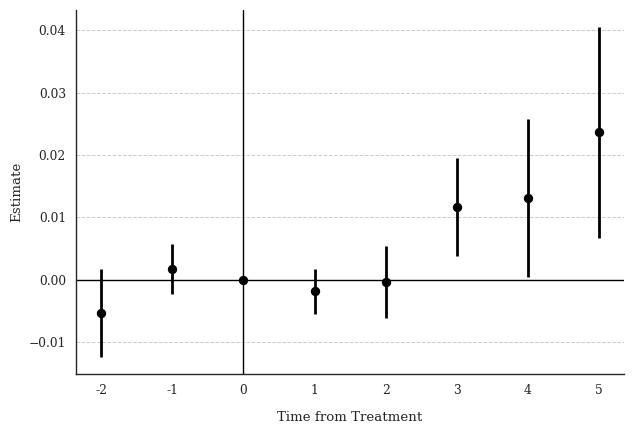

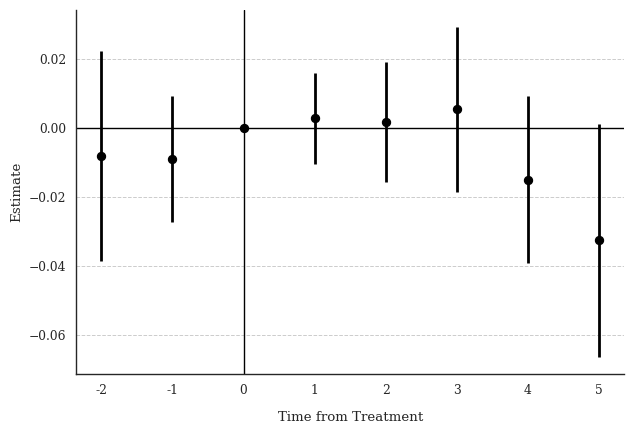

In [34]:
DID(df_ud, 'pres', 1995, 'RN')
DID(df_ud, 'pres', 1995, 'PS')

DID(df_ud, 'leg', 1997, 'RN')
DID(df_ud, 'leg', 1997, 'PS')

In [35]:
import scipy.stats as st

# Les valeurs de votre test Placebo
estimate_placebo = -0.005310 
se_placebo =  0.001607 

# 1. Calcul du Z-score
z_score = estimate_placebo / se_placebo

# 2. Calcul de la p-value bilatérale
p_value = 2 * (1 - st.norm.cdf(abs(z_score)))

print(f"Z-score : {z_score:.3f}")
print(f"P-value du Placebo : {p_value:.3f}")

Z-score : -3.304
P-value du Placebo : 0.001
